In [1]:
import os
import sys

# Get the absolute path of the directory containing the notebook (notebooks/)
current_dir = os.path.abspath('')

# Add the parent directory (SingleWordProductionDutch/) to the system path
# This allows Python to find 'src'
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)


%load_ext autoreload
%autoreload 2

import numpy as np
import scipy.signal
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from scipy.signal import welch

import pandas as pd
import numpy.matlib as matlib
import scipy
import scipy.stats
import scipy.io.wavfile
import scipy.fftpack
from scipy.stats import pearsonr
from pynwb import NWBHDF5IO

from somata.basic_models import OscillatorModel as Osc
from somata.oscillator_search import IterativeOscillatorModel as IterOsc
from somata.oscillator_search.helper_functions import get_knee
from specparam import SpectralModel

from phaseEM import *
from extract_features import *
from channel_evaluation import *
import config as cfg
from reconstruction_minimal import *
path_somata = '/Users/lisa/Documents/DSAI_year2/SingleWordProductionDutch-1/somata'

In [2]:
#Get top channels+regions 

#for participant in participants["participant_id"][:2]:
participant = "sub-07"

#Load data
io = NWBHDF5IO(os.path.join(cfg.PATH_BIDS,participant,'ieeg',f'{participant}_task-wordProduction_ieeg.nwb'), 'r')
nwbfile = io.read()
#sEEG
eeg = nwbfile.acquisition['iEEG'].data[:]
eeg_sr = 1024
io.close()

t_segment = 10 #we don't want to take the full 300 seconds for just calibrating, for now, take 10s
n_samples_to_use = int(t_segment * eeg_sr)
eeg = eeg[:n_samples_to_use, :]

eeg = scipy.signal.detrend(eeg, axis=0)

#remove (harmonics of) line noise
for i in range (0,5):
    sos = scipy.signal.iirfilter(4, [(i*100+49)/(eeg_sr/2),(i*100+51)/(eeg_sr/2)],btype='bandstop',output='sos')
    eeg = scipy.signal.sosfiltfilt(sos,eeg,axis=0)





channel: 96 , region:  ctx_lh_S_temporal_transverse
channel: 95 , region:  Left-Cerebral-White-Matter
channel: 94 , region:  Left-Cerebral-White-Matter
channel: 97 , region:  ctx_lh_S_temporal_transverse
channel: 1 , region:  Left-Amygdala
Multitaper Spectrogram Properties: 
     Spectral Resolution: 4.0Hz
     Window Length: 1.0s
     Window Step: 0.0498046875s
     Time Half-Bandwidth Product: 2
     Number of Tapers: 3
     Frequency Range: 0-512.0Hz
     NFFT: 16384
     Detrend: constant



/Users/lisa/Library/Python/3.9/lib/python/site-packages/somata/multitaper/multitaper_spectrogram_python.py:297: UserWarning: Window step size is not divisible by sampling frequency. Adjusting window step size to 0.0498046875 seconds
  warnings.warn('Window step size is not divisible by sampling frequency. Adjusting window step size to ' +



 Multitaper compute time: 0.25 seconds


'\nfor ch in top_channels:\n    io1 = IterOsc(eeg[:, ch], eeg_sr, noise_start=None, osc_range=7)\n    \n    _ = io1.plot_mtm()  # plot multitaper spectrogram and mean spectrum\n    _ = io1.plot_trace()  # plot raw time trace\n'

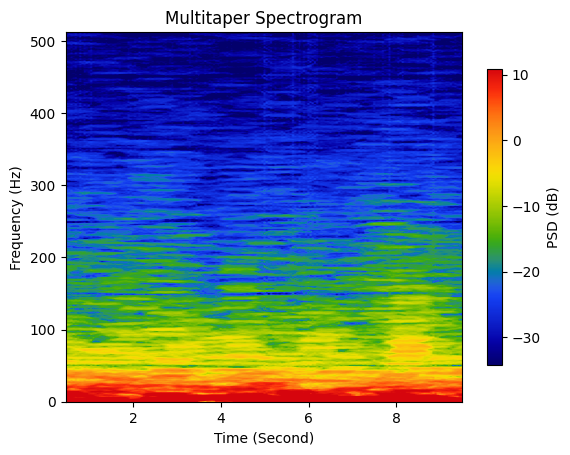

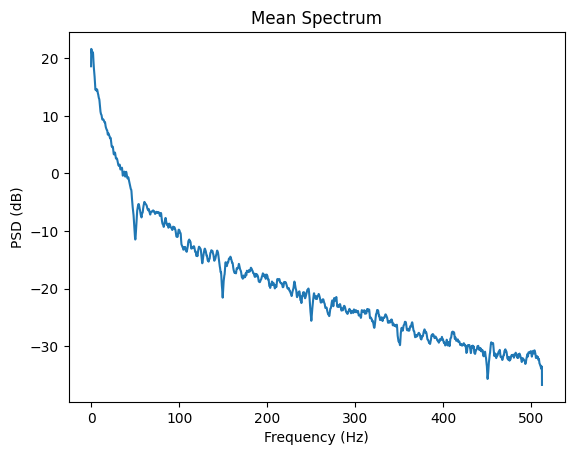

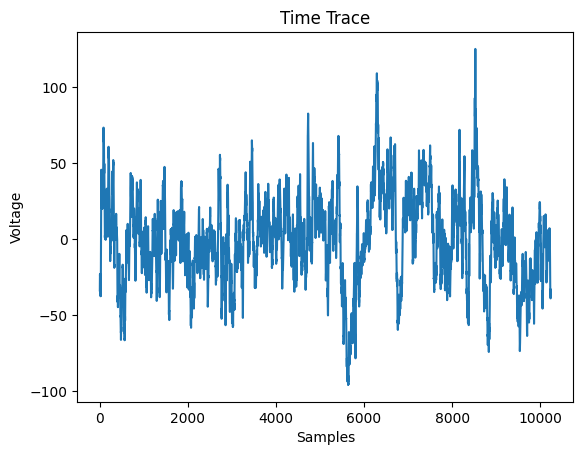

In [18]:
#Plot raw data of top correlating channel

top_channels, correlation= highest_hg_mel_correlations(participant)

for ch in top_channels:
    print("channel:", ch,", region: ", get_channel_region(participant, ch))


io1 = IterOsc(eeg[:, top_channels[0]], eeg_sr, noise_start=None, osc_range=7)
    
_ = io1.plot_mtm()  # plot multitaper spectrogram and mean spectrum
_ = io1.plot_trace()  # plot raw time trace

'''
for ch in top_channels:
    io1 = IterOsc(eeg[:, ch], eeg_sr, noise_start=None, osc_range=7)
    
    _ = io1.plot_mtm()  # plot multitaper spectrogram and mean spectrum
    _ = io1.plot_trace()  # plot raw time trace
'''
    

EM learning on the initial oscillator
Prior input parameters: {'R_hyperparameter': 0.1, 'Q_hyperparameter': None, 'R_sigma2': np.float64(0.2672508431942233), 'Q_sigma2': 'MLE'}
Iteration 0 completed:
 nstate   = 2     ncomp    = 1
 nchannel = 1     ntime    = 10240
 nmodel   = 1
 components = [Osc(0)<6460>]
 F  .shape = (2, 2)     Q  .shape = (2, 2)
 mu0.shape = (2, 1)     S0 .shape = (2, 2)
 G  .shape = (1, 2)     R  .shape = (1, 1)
 y  .shape = (1, 10240) Fs = 1024.0 Hz
 damping a = [0.994]
 freq Hz   = [1.5]
 sigma2    = [5.641]
 obs noise R = [[0.205]]
 dc index  = None

AR: add freq = 67.49 Hz, add radius = 0.729, add sigma2 = 0.297
Prior input parameters: {'R_hyperparameter': 0.1, 'Q_hyperparameter': None, 'R_sigma2': np.float64(0.2672508431942233), 'Q_sigma2': 'MLE'}
Iteration 1 completed:
 nstate   = 4     ncomp    = 2
 nchannel = 1     ntime    = 10240
 nmodel   = 1
 components = [Osc(0)<6850>, Osc(0)<6610>]
 F  .shape = (4, 4)     Q  .shape = (4, 4)
 mu0.shape = (4, 1)     S0

KeyboardInterrupt: 

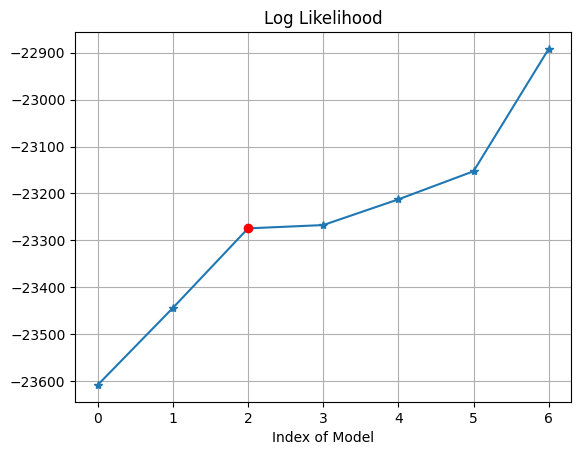

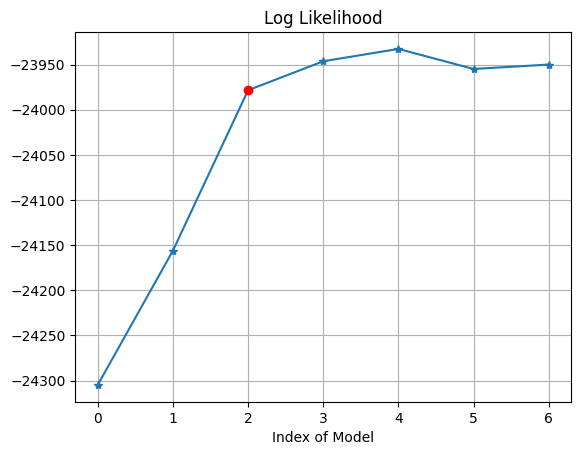

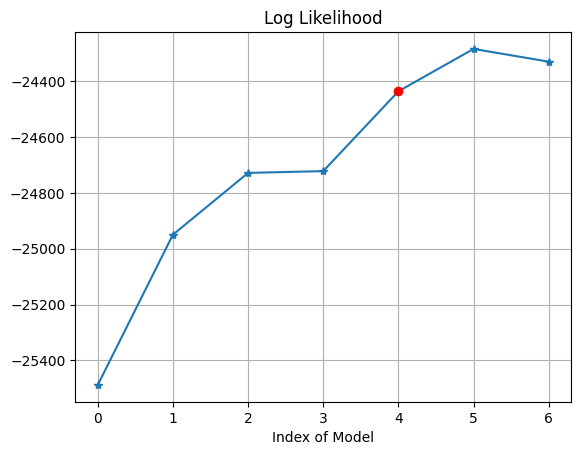

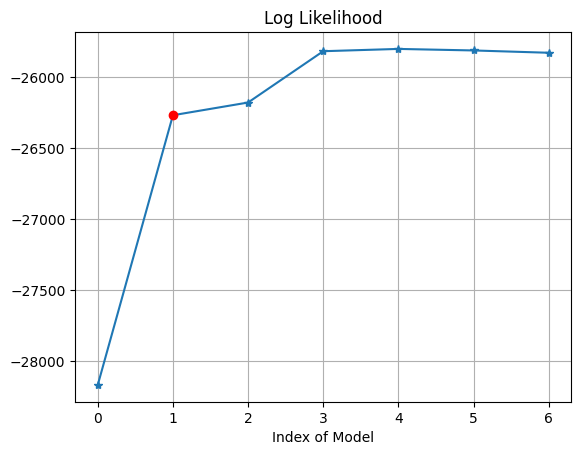

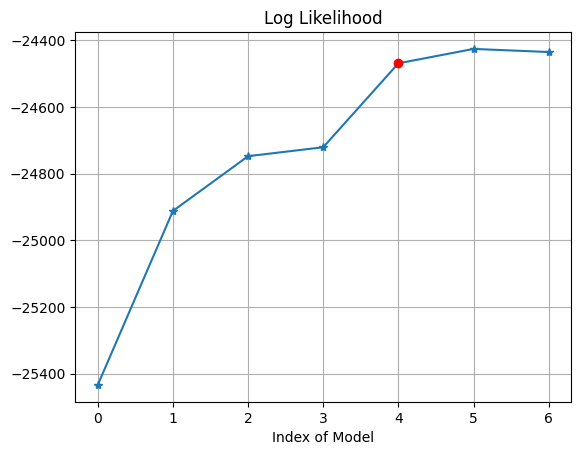

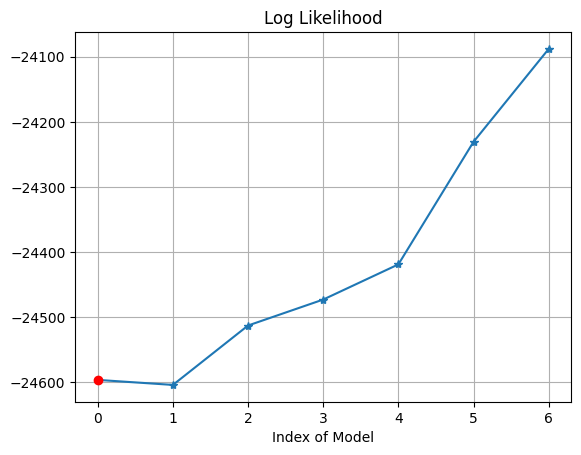

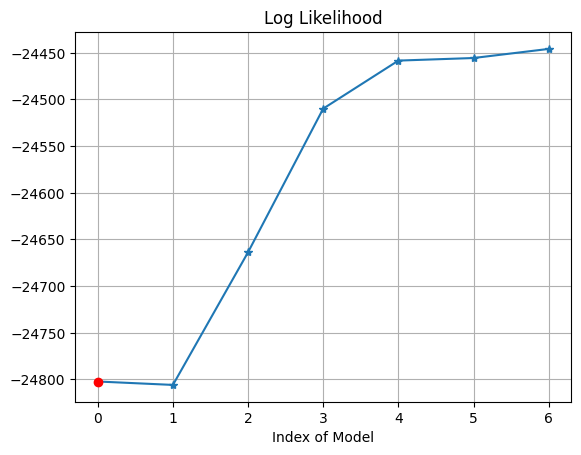

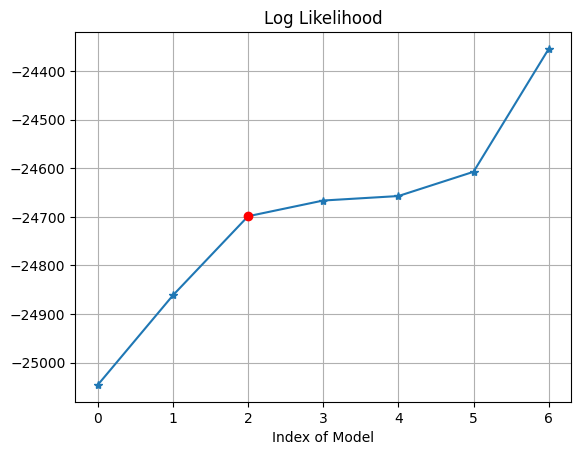

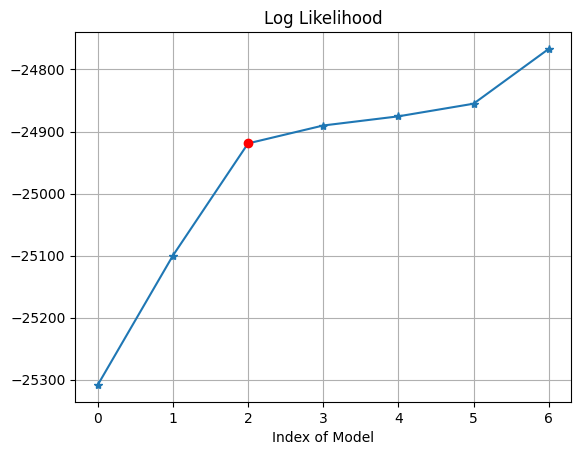

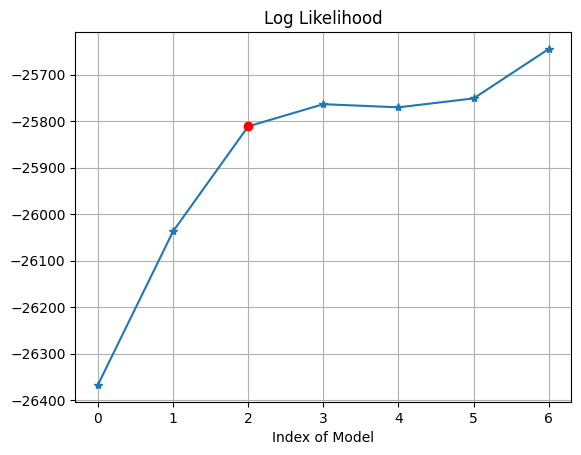

In [8]:
#SOMATA peak detection

channel_results={}
j=0

path_somata =  '/Users/lisa/Documents/DSAI_year2/SingleWordProductionDutch-1/somata'

#for ch in top_channels:

n_channels = eeg.shape[1]

for ch in range(n_channels):
# -run IterOsc for the channel -
    io1 = IterOsc(eeg[:, ch], eeg_sr, noise_start=None, osc_range=7)
    io1.iterate(freq_res=1, plot_fit=False, verbose=False) 

    # find knee index
    ll_vec = io1.ll
    knee_idx = get_knee(ll_vec)
    
    # take model of knee index
    best_model_for_ch = io1.get_knee_osc()

    #adapt the optimal model_idx if it returns 0 as optimal (by seeing if it can find a hg osc)
    if knee_idx == 0: #go through each iteration, when finding one with a hg osc, pick that as best
        for i, model in enumerate(io1.fitted_osc[knee_idx+1:], start=knee_idx+1): #io1.fitted_osc contains the Osc objects for each step of the search (1 oscillator, then 2, then 3, etc.)
            last_freq = model.freq[-1]
            
            # find for a last frequency is in HG range, to pick that as best model
            if last_freq >= 70 and last_freq<=170:
                best_model_for_ch = model
                knee_idx = i
                break
        #if didn't find a hg osc, force knee_idx to 2
        if knee_idx == 0:
            knee_idx = 2
        print(f'changed knee_idx from 0 to {knee_idx}')


    # if the next model (at knee_idx+1)gives us a frequency in HG range we don't track yet
    if knee_idx + 1 < len(io1.fitted_osc): #first check if we're not already at the last iteration
        last_freq_next_model = io1.fitted_osc[knee_idx+1].freq[-1]
        if 70 <= last_freq_next_model <= 170:
            # ceck: Is this new frequency at least 5Hz away from all current frequencies? to ensure it's not redundant with any existing oscillator
            freq_diffs = np.abs(best_model_for_ch.freq - last_freq_next_model)
            if np.all(freq_diffs > 5):
                knee_idx = knee_idx + 1
                best_model_for_ch =  io1.fitted_osc[knee_idx]
                print(f'found another hg freq at knee_idx +1 (={knee_idx})')
                print(f' freqs: {best_model_for_ch.freq}')
                assert len(best_model_for_ch.freq) == knee_idx +1, 'invalid kneeidx update'

    
    #Examine the final oscillator model selected by the iOsc+ algorithm.
    print(best_model_for_ch)

    #Plot log-likelihood and the selected model (may not be the highest likelihood).
    #_ = io1.plot_log_likelihoods()
    
    #save results for optimal model
    channel_results[j] = { #channel_results[ch_idx] = {
        'channel': ch,
        'knee_n_osc': knee_idx + 1,
        'logL': ll_vec[knee_idx],
        'freqs': best_model_for_ch.freq,
        'damping': best_model_for_ch.a,
        'sigma2': best_model_for_ch.sigma2, 
        'obs_noise_R': best_model_for_ch.R 
    }
    print("channel", ch)
    print(channel_results[j])
    _ = io1.plot_log_likelihoods()
    j=j+1


np.save(os.path.join(path_somata,f'{participant}_somata_results.npy'), channel_results)



In [19]:
#parralel somata 

from joblib import Parallel, delayed
import gc

def process_channel(ch, eeg_data, eeg_sr):
    io1 = IterOsc(eeg_data, eeg_sr, noise_start=None, osc_range=7)
    io1.iterate(freq_res=1, plot_fit=False, verbose=False)

    ll_vec = io1.ll
    knee_idx = get_knee(ll_vec)
    best_model_for_ch = io1.get_knee_osc()

    '''
    # if the model chose knee idx 0, look ahead
    if knee_idx == 0:
        for i, model in enumerate(io1.fitted_osc[1:], start=1):
            if 70 <= model.freq[-1] <= 170:
                best_model_for_ch = model
                knee_idx = i
                break
        if knee_idx == 0:
            knee_idx = 2
        print(f'changed knee_idx from 0 to {knee_idx}')
        '''
        # if the model chose knee idx 0 or 1 (so 1 or 2 oscilators), look ahead
    if knee_idx <2:
        for i, model in enumerate(io1.fitted_osc[1:], start=1):
            if 70 <= model.freq[-1] <= 170:
                best_model_for_ch = model
                knee_idx = i
                break
        if knee_idx <2:
            knee_idx = 2
            best_model_for_ch = io1.fitted_osc[2]
        #print(f'changed knee_idx to {knee_idx}')

    # look ahead if there is an hg osc next we want to include
    if knee_idx + 1 < len(io1.fitted_osc):
        next_model = io1.fitted_osc[knee_idx+1]
        last_freq_next = next_model.freq[-1]
        if 70 <= last_freq_next <= 170:
            freq_diffs = np.abs(best_model_for_ch.freq - last_freq_next)
            if np.all(freq_diffs > 5):
                knee_idx += 1
                best_model_for_ch = next_model
                #print(f'found another hg freq at knee_idx +1 (={knee_idx})')

    #print("channel", ch)
    #print("freqs", best_model_for_ch.freq)
    
    returns = {
        'channel': ch,
        'knee_n_osc': knee_idx + 1,
        'logL': ll_vec[knee_idx],
        'freqs': best_model_for_ch.freq,
        'damping': best_model_for_ch.a,
        'sigma2': best_model_for_ch.sigma2, 
        'obs_noise_R': best_model_for_ch.R 
    }
    del io1
    del best_model_for_ch
    gc.collect()
    return returns


n_channels = eeg.shape[1]
print(participant, n_channels)

# Run with limited jobs and tqdm to keep the kernel awake
from tqdm.auto import tqdm
eeg_sr = 1024

results_list = Parallel(n_jobs=4)( # Only 4 jobs to save RAM
    delayed(process_channel)(ch, eeg[:, ch], eeg_sr) 
    for ch in tqdm(range(n_channels), desc="Running SOMATA")
)


# Convert list of results back to a dictionary
channel_results = {i: res for i, res in enumerate(results_list)}

# Save
np.save(os.path.join(path_somata, f'{participant}_somata_results.npy'), channel_results)

sub-10 122


Running SOMATA:   0%|          | 0/122 [00:00<?, ?it/s]

In [4]:
#average frequency template constructor by finding clusters in somata results

from sklearn.neighbors import KernelDensity
from scipy.signal import find_peaks


def plot_density_template(results_dict, template_freqs, s, dens, all_freqs):
    plt.figure(figsize=(12, 6))
    
    # plot the smooth KDE density curve
    plt.plot(s, dens, color='black', lw=2, label='Kernel Density (KDE)')
    plt.fill_between(s.flatten(), dens, alpha=0.2, color='gray')
    
    # plot the individual frequencies found by SOMATA (the blue vertical lines)
    plt.vlines(all_freqs, ymin=0, ymax=dens.max()*0.05, color='blue', alpha=0.3, label='SOMATA Freqs')
    
    # mark the final chosen template frequencies
    for f in template_freqs:
        # Get density value at this frequency to place the marker
        idx = np.argmin(np.abs(s - f))
        plt.plot(f, dens[idx], "ro", markersize=8)
        plt.annotate(f"{f:.1f}Hz", (f, dens[idx]), textcoords="offset points", 
                     xytext=(0,10), ha='center', fontweight='bold', color='red')
    
    plt.title('Frequency Cluster Analysis & Template Selection', fontsize=14)
    plt.xlabel('Frequency (Hz)', fontsize=12)
    plt.ylabel('Density (Probability)', fontsize=12)
    plt.xlim(0, 170)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def build_density_template(results_dict, nr_osc = 3, min_hg_osc=2):
    all_freqs = []
    for ch, data in results_dict.items():
        if any(70 <= f <= 170 for f in data['freqs']):
            all_freqs.extend(data['freqs'])

    print(f'nr of frequencies in somata results in total: {len(all_freqs)}')
    #print(f'all frequencies found: {sorted(all_freqs)}')
    # Reshape for sklearn
    X = np.array(all_freqs).reshape(-1, 1)
    
    # 1. Fit KDE (bandwidth=3 means it treats freqs within ~3-5Hz as 'together')
    kde = KernelDensity(kernel='gaussian', bandwidth=2).fit(X)
    
    # 2. Evaluate density across the spectrum (0 to 170 Hz)
    s = np.linspace(0, 170, 1000).reshape(-1, 1)
    log_dens = kde.score_samples(s)
    dens = np.exp(log_dens)
    
    # 3. Find peaks in the density
    peaks, _ = find_peaks(dens, distance=5) # distance ensures peaks are at least 5Hz apart
    peak_freqs = s[peaks].flatten()

    print(f'peak_freqs: {peak_freqs}')
    

    # For non HG, pick the top nr_osc strongest peaks
    # Sort peaks by their density (height)
    peaks_sorted = sorted(peak_freqs, key=lambda f: dens[np.argmin(np.abs(s-f))], reverse=True)
    template = set(peaks_sorted[:nr_osc])

    
    #if less hg peaks included then minimal:
    if len([f for f in template if 70 <= f <= 170]) <min_hg_osc:
        hg_peaks = [f for f in peak_freqs if 70 <= f <= 170]
        # Sort HG peaks by their density (height)
        hg_peaks_sorted = sorted(hg_peaks, key=lambda f: dens[np.argmin(np.abs(s-f))], reverse=True)
        template.update(hg_peaks_sorted[:min_hg_osc])

    plot_density_template(results_dict, template, s, dens, all_freqs)
    
    return sorted(list(template))


def get_template_parameters(results_dict, template_freqs, window=7):
    final_a = []
    final_s = []
    
    for target_f in template_freqs:
        window = 2 if target_f < 10 else 7
        matching_as = []
        matching_ss = []
        
        for ch, data in results_dict.items():
            # Extract lists from the dictionary
            ch_freqs = np.array(data['freqs'])
            ch_as = np.array(data['damping'])
            ch_ss = np.array(data['sigma2'])
            
            # Find indices where channel frequency is close to the template peak
            matches = np.where(np.abs(ch_freqs - target_f) <= window)[0]
            
            if len(matches) > 0:
                matching_as.extend(ch_as[matches])
                matching_ss.extend(ch_ss[matches])
        
        # Calculate mean for this peak. Fallback to sensible defaults if no match.
        if matching_as:
            final_a.append(np.mean(matching_as))
            final_s.append(np.mean(matching_ss))
        else:
            # Default values if a cluster has no close contributors (shouldn't happen)
            final_a.append(0.98) 
            final_s.append(0.5)
            
    return final_a, final_s

[ 1.57171376 72.89608773 30.67527927]
[ 1.61172049 32.21539268 76.49096605]
[ 1.46762755 32.76762149 77.56405255 22.93725585 12.44592291]
[ 2.17824134 27.86930719 74.8655711 ]
[  1.92596477  32.81044039  74.30780164  20.22396053 182.98297061
 120.55085829]
120
nr of frequencies in somata results in total: 481
peak_freqs: [  1.7017017   13.27327327  27.73773774  61.26126126  73.51351351
  84.06406406  96.14614615 103.46346346 116.22622623 124.05405405
 130.69069069 151.11111111 163.02302302]


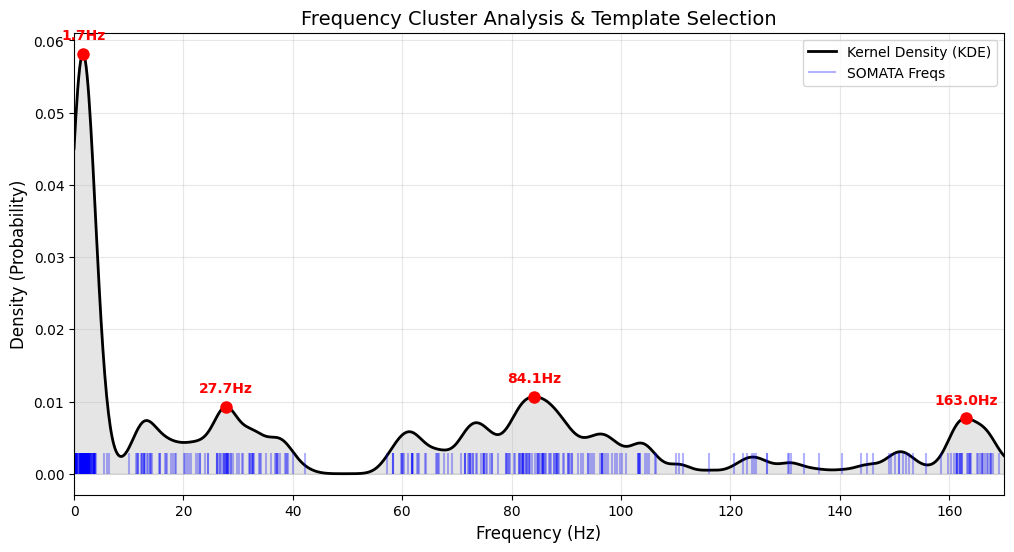


--- Final Consensus Template ---
Freq:   1.70 Hz | a: 0.9799 | s: 4.0669
Freq:  27.74 Hz | a: 0.9824 | s: 0.7680
Freq:  84.06 Hz | a: 0.9051 | s: 0.3751
Freq: 163.02 Hz | a: 0.8763 | s: 0.2810


In [10]:
#for a single participant
#first: run somata for each channel and save the results in participant_somata_results
participant = "sub-07"
somata_results = np.load(os.path.join(path_somata,f'{participant}_somata_results.npy'),allow_pickle=True).item()

#gather all channels that have a peak in hg range (that we thus want to use for our base osc template)    
has_hg_osc = set()
for idx, data in somata_results.items():
    if any(70 <= f <= 170 for f in data['freqs']):
        #has_hg_osc.add(int(data['channel']))
        has_hg_osc.add(idx)
    if idx<5:
        print(data['freqs'])

print(len(has_hg_osc))
hg_subset_results = {idx: somata_results[idx] for idx in has_hg_osc}
template_freqs = build_density_template(hg_subset_results, nr_osc = 3, min_hg_osc=2)
template_a, template_s = get_template_parameters(hg_subset_results, template_freqs) 

print("\n--- Final Consensus Template ---")
for i, f in enumerate(template_freqs):
    print(f"Freq: {f:6.2f} Hz | a: {template_a[i]:.4f} | s: {template_s[i]:.4f}")

nr of frequencies in somata results in total: 67
peak_freqs: [  1.36136136   5.61561562  20.42042042  36.75675676  56.83683684
  71.98198198  84.91491491  98.6986987  104.31431431 113.16316316
 118.26826827 124.56456456 148.04804805]


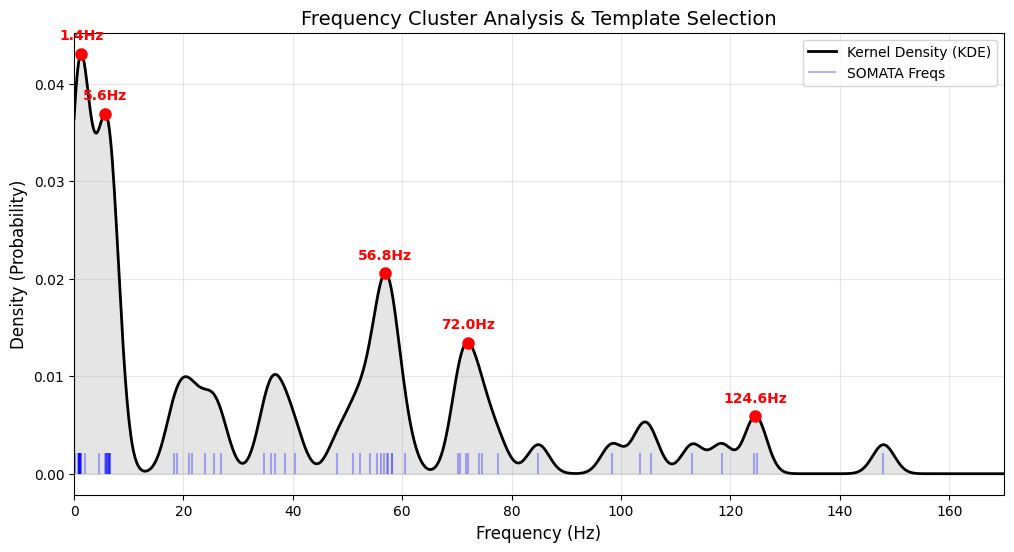

13

--- Final Consensus Template ---
Freq:   1.36 Hz | a: 0.9973 | s: 6.5603
Freq:   5.62 Hz | a: 0.9988 | s: 4.9930
Freq:  56.84 Hz | a: 0.9729 | s: 0.4984
Freq:  71.98 Hz | a: 0.9633 | s: 0.3388
Freq: 124.56 Hz | a: 0.8097 | s: 0.1097


In [29]:

participant = "sub-06"

somata_results = np.load(os.path.join(path_somata,f'{participant}_somata_results.npy'),allow_pickle=True).item()

#gather all channels that have a peak in hg range (that we thus want to use for our base osc template)    
has_hg_osc = set()
for idx, data in somata_results.items():
    if any(70 <= f <= 170 for f in data['freqs']):
        #has_hg_osc.add(int(data['channel']))
        has_hg_osc.add(idx)

hg_subset_results = {idx: somata_results[idx] for idx in has_hg_osc}
template_freqs = build_density_template(hg_subset_results)
template_a, template_s = get_template_parameters(hg_subset_results, template_freqs) 
print(len(has_hg_osc))
print("\n--- Final Consensus Template ---")
for i, f in enumerate(template_freqs):
    print(f"Freq: {f:6.2f} Hz | a: {template_a[i]:.4f} | s: {template_s[i]:.4f}")

nr of frequencies in somata results in total: 481
peak_freqs: [  1.7017017   13.27327327  27.73773774  61.26126126  73.51351351
  84.06406406  96.14614615 103.46346346 116.22622623 124.05405405
 130.69069069 151.11111111 163.02302302]


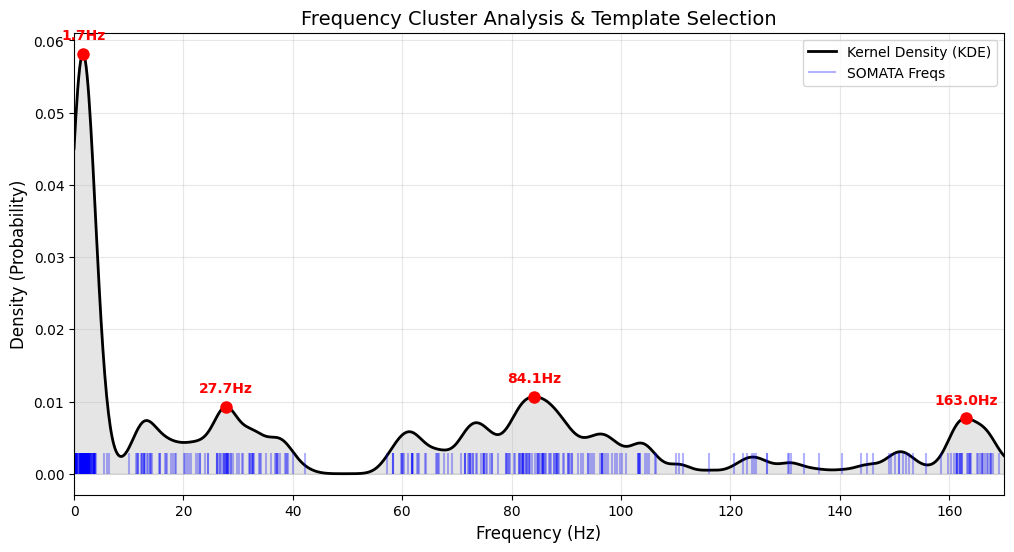

{'freqs': array([ 1.57171376, 72.89608773, 30.67527927]), 'Fs': 1024, 'ampVec': array([0.99555024, 0.9515532 , 0.98708154]), 'sigmaFreqs': array([3.97994972, 0.32491478, 0.21023946]), 'sigmaObs': 1, 'windowSize': 2000, 'lowFreqBand': None}
{'freqs': array([ 1.61172049, 32.21539268, 76.49096605]), 'Fs': 1024, 'ampVec': array([0.9966205 , 0.98246428, 0.96231847]), 'sigmaFreqs': array([4.6353358 , 0.4630824 , 0.18033479]), 'sigmaObs': 1, 'windowSize': 2000, 'lowFreqBand': None}
{'freqs': array([ 1.46762755, 32.76762149, 77.56405255, 22.93725585, 12.44592291]), 'Fs': 1024, 'ampVec': array([0.99758477, 0.98151142, 0.95492596, 0.99302318, 0.99340544]), 'sigmaFreqs': array([2.94761495, 1.34029573, 0.28380785, 0.25067668, 0.56827255]), 'sigmaObs': 1, 'windowSize': 2000, 'lowFreqBand': None}
{'freqs': array([ 2.17824134, 27.86930719, 74.8655711 ]), 'Fs': 1024, 'ampVec': array([0.99810887, 0.99059548, 0.95936803]), 'sigmaFreqs': array([3.88624603, 3.76668931, 0.22734596]), 'sigmaObs': 1, 'window

'          \n    run_extract_features(participant, initParams_list, SSPE=True)\nreconstruct(["sub-10"]\n'

In [17]:
# Build initParams list for all channels according to rule 1.1

for participant in ["sub-07"]:
    somata_results = np.load(os.path.join(path_somata,f'{participant}_somata_results.npy'),allow_pickle=True).item()
    
    #gather all channels that have a peak in hg range (that we thus want to use for our base osc template)    
    has_hg_osc = set()
    for idx, data in somata_results.items():
        if any(70 <= f <= 170 for f in data['freqs']):
            #has_hg_osc.add(int(data['channel']))
            has_hg_osc.add(idx)
    hg_subset_results = {idx: somata_results[idx] for idx in has_hg_osc}
    template_freqs = build_density_template(hg_subset_results)
    template_a, template_s = get_template_parameters(hg_subset_results, template_freqs) 
    
    initParams_list = []
    for ch, _ in somata_results.items():
        if any(70 <= f <= 170 for f in data['freqs']):
            initParams = {
                "freqs": somata_results[ch]['freqs'],
                "Fs": eeg_sr,
                "ampVec": somata_results[ch]['damping'],
                "sigmaFreqs": somata_results[ch]['sigma2'],
                "sigmaObs": 1,
                "windowSize": 2000,
                "lowFreqBand": None
            }
        else:
            initParams = {
                "freqs": template_freqs,
                "Fs": eeg_sr,
                "ampVec": template_a,
                "sigmaFreqs": template_s,
                "sigmaObs": 1,
                "windowSize": 2000,
                "lowFreqBand": None
            }
        initParams_list.append(initParams)
    for i in range (0,5):
        print(initParams_list[i])
'''          
    run_extract_features(participant, initParams_list, SSPE=True)
reconstruct(["sub-10"]
'''

running decoder for rule 1.2
sub-06 has mean correlation of 0.809089
sub-07 has mean correlation of 0.703751
sub-08 has mean correlation of 0.582714
sub-09 has mean correlation of 0.522065
nr of frequencies in somata results in total: 67
peak_freqs: [  1.36136136   5.61561562  20.42042042  36.75675676  56.83683684
  71.98198198  84.91491491  98.6986987  104.31431431 113.16316316
 118.26826827 124.56456456 148.04804805]


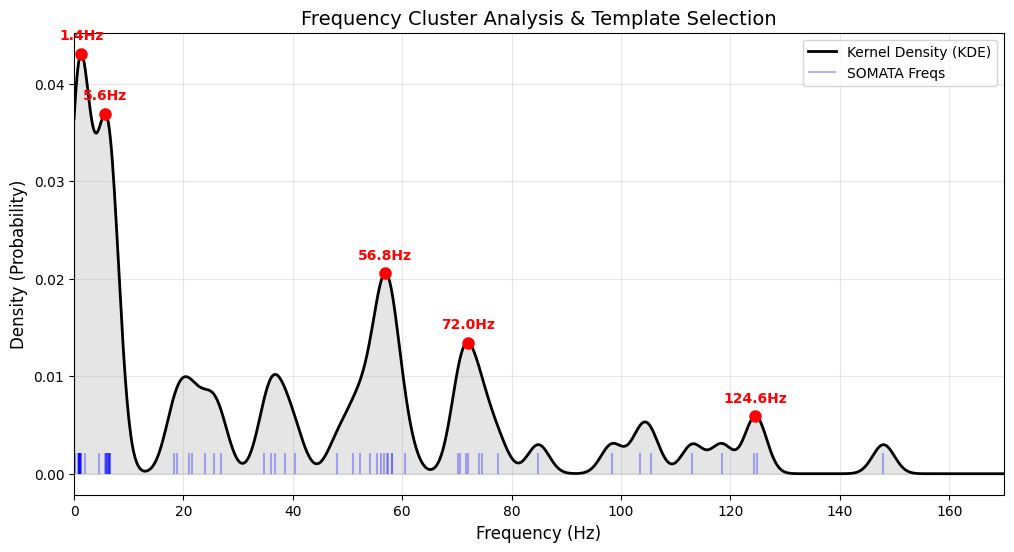

Starting parallel SSPE extraction for 127 channels...
extracted features
nr of frequencies in somata results in total: 481
peak_freqs: [  1.7017017   13.27327327  27.73773774  61.26126126  73.51351351
  84.06406406  96.14614615 103.46346346 116.22622623 124.05405405
 130.69069069 151.11111111 163.02302302]


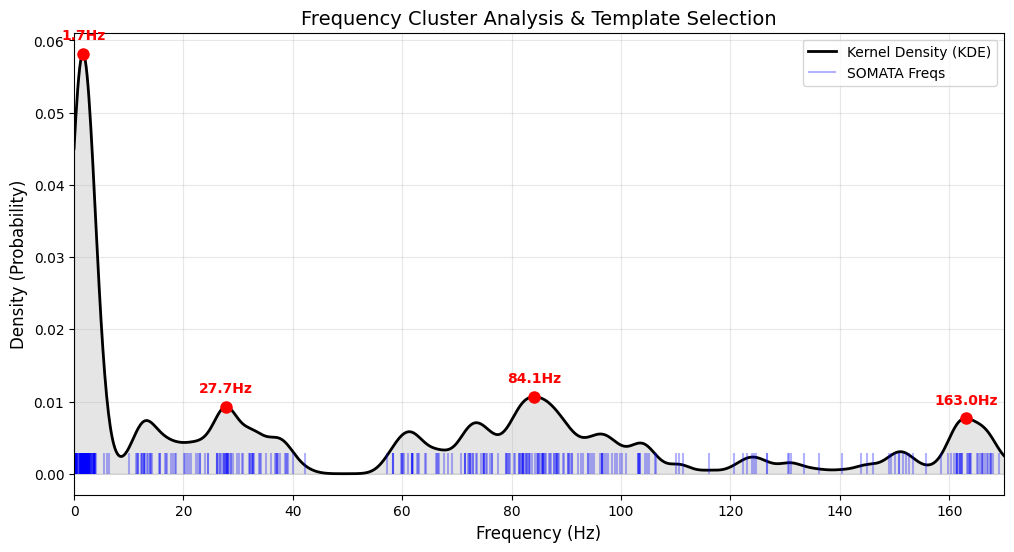

Starting parallel SSPE extraction for 127 channels...
extracted features
nr of frequencies in somata results in total: 174
peak_freqs: [  1.02102102   9.6996997   25.86586587  35.73573574  52.92292292
  62.45245245  77.25725726  89.33933934  96.82682683 102.1021021
 111.46146146 117.41741742 159.44944945]


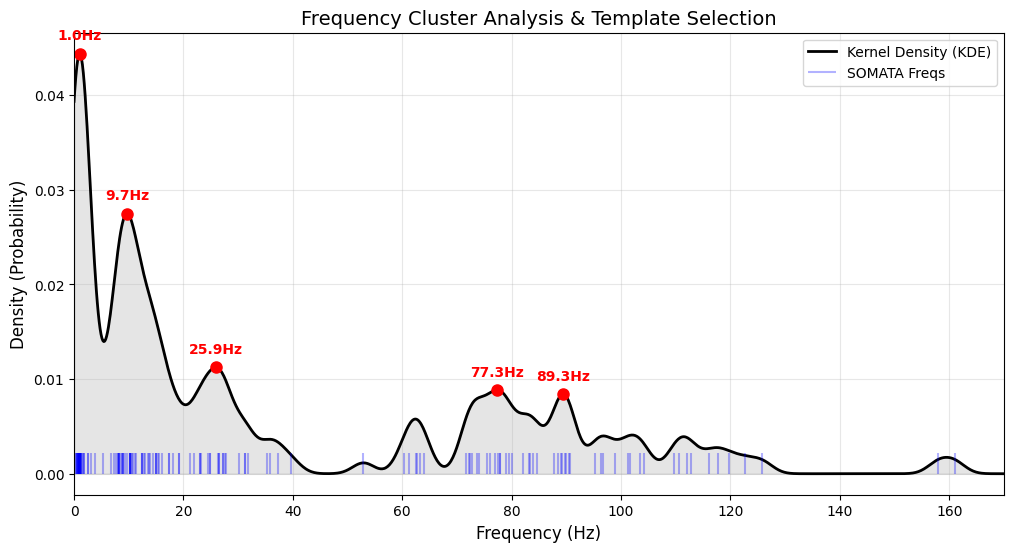

Starting parallel SSPE extraction for 54 channels...
extracted features
nr of frequencies in somata results in total: 304
peak_freqs: [  1.53153153  13.61361361  39.13913914  55.64564565  64.66466466
  82.53253253  89.33933934 102.27227227 112.31231231 135.11511512
 155.02502503 162.002002  ]


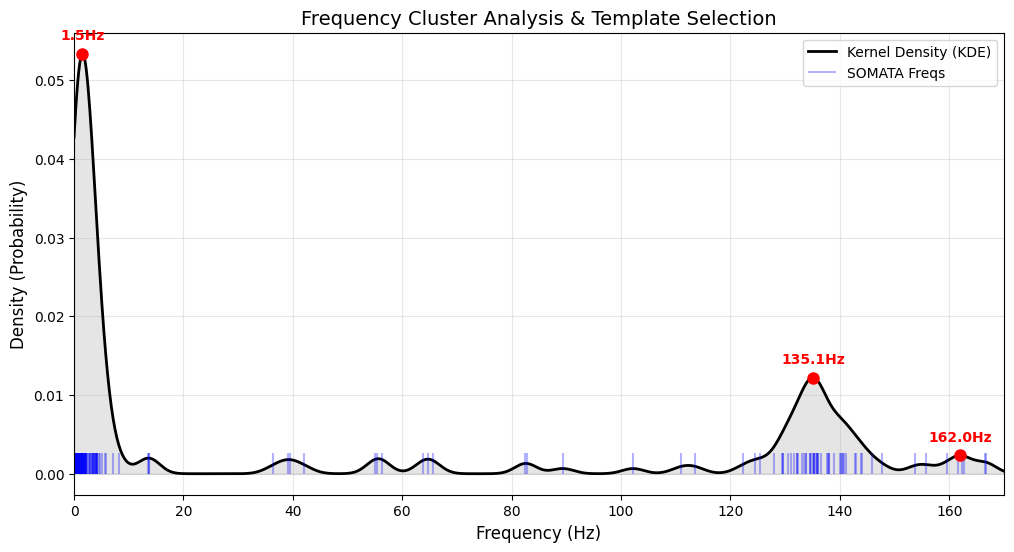

Starting parallel SSPE extraction for 117 channels...
extracted features
running decoder for rule 2
sub-06 has mean correlation of 0.794323
sub-07 has mean correlation of 0.677045
sub-08 has mean correlation of 0.523885
sub-09 has mean correlation of 0.533890


In [17]:
# Build initParams list for all channels according to rule 1.2
eeg_sr = 1024
for participant in ["sub-06", "sub-07", "sub-08", "sub-09"]:
    somata_results = np.load(os.path.join(path_somata,f'{participant}_somata_results.npy'),allow_pickle=True).item()
    
    #gather all channels that have a peak in hg range (that we thus want to use for our base osc template)    
    has_hg_osc = set()
    for idx, data in somata_results.items():
        if any(70 <= f <= 170 for f in data['freqs']):
            #has_hg_osc.add(int(data['channel']))
            has_hg_osc.add(idx)
    hg_subset_results = {idx: somata_results[idx] for idx in has_hg_osc}
    template_freqs = build_density_template(hg_subset_results)
    template_a, template_s = get_template_parameters(hg_subset_results, template_freqs) 
    template_freqs = np.array(template_freqs)
    template_a = np.array(template_a)
    template_s = np.array(template_s)
    
    # Find indices where template frequencies are in the HG range
    hg_mask = (template_freqs >= 70) & (template_freqs <= 170)
    
    hg_only_f = template_freqs[hg_mask]
    hg_only_a = template_a[hg_mask]
    hg_only_s = template_s[hg_mask]
    
    initParams_list = []
    for ch, _ in somata_results.items():
        initParams = {
            "freqs": somata_results[ch]['freqs'],
            "Fs": eeg_sr,
            "ampVec": somata_results[ch]['damping'],
            "sigmaFreqs": somata_results[ch]['sigma2'],
            "sigmaObs": 1,
            "windowSize": 2000,
            "lowFreqBand": None
        }
        if not any(70 <= f <= 170 for f in data['freqs']):
            initParams = {
                "freqs": list(somata_results[ch]['freqs']) + list(hg_only_f),
                "Fs": eeg_sr,
                "ampVec": list(somata_results[ch]['damping']) + list(hg_only_a),
                "sigmaFreqs": list(somata_results[ch]['sigma2']) + list(hg_only_s),
                "sigmaObs": 1,
                "windowSize": 2000,
                "lowFreqBand": None
            }
            #initParams["freqs"].extend(hg_only_f)
            #initParams["ampVec"].extend(hg_only_a)
            #initParams["sigmaFreqs"].extend(hg_only_s)
        
        initParams_list.append(initParams)
    
    run_extract_features(participant, initParams_list, SSPE=True)

print("running decoder for rule 1.2")
reconstruct(["sub-06", "sub-07", "sub-08", "sub-09"])



# Build initParams list for all channels according to rule 2
for participant in ["sub-06", "sub-07", "sub-08", "sub-09"]:
    somata_results = np.load(os.path.join(path_somata,f'{participant}_somata_results.npy'),allow_pickle=True).item()
      
    has_hg_osc = set()
    for idx, data in somata_results.items():
        if any(70 <= f <= 170 for f in data['freqs']):
            #has_hg_osc.add(int(data['channel']))
            has_hg_osc.add(idx)

    hg_subset_results = {idx: somata_results[idx] for idx in has_hg_osc}
    template_freqs = build_density_template(hg_subset_results)
    template_a, template_s = get_template_parameters(hg_subset_results, template_freqs) 
    
    initParams = {
        "freqs": template_freqs,
        "Fs": eeg_sr,
        "ampVec": template_a,
        "sigmaFreqs": template_s,
        "sigmaObs": 1,
        "windowSize": 2000,
        "lowFreqBand": None
    }
    initParams_list = [initParams]*len(somata_results.items())
    
    run_extract_features(participant, initParams_list, SSPE=True)


print("running decoder for rule 2")
reconstruct(["sub-06", "sub-07", "sub-08", "sub-09"])

nr of frequencies in somata results in total: 346
peak_freqs: [  1.19119119  11.06106106  19.90990991  28.41841842  33.18318318
  41.52152152  55.98598599  75.8958959   79.80980981  90.02002002
 100.57057057 108.3983984  113.84384384 129.83983984 141.92192192
 157.57757758 169.48948949]


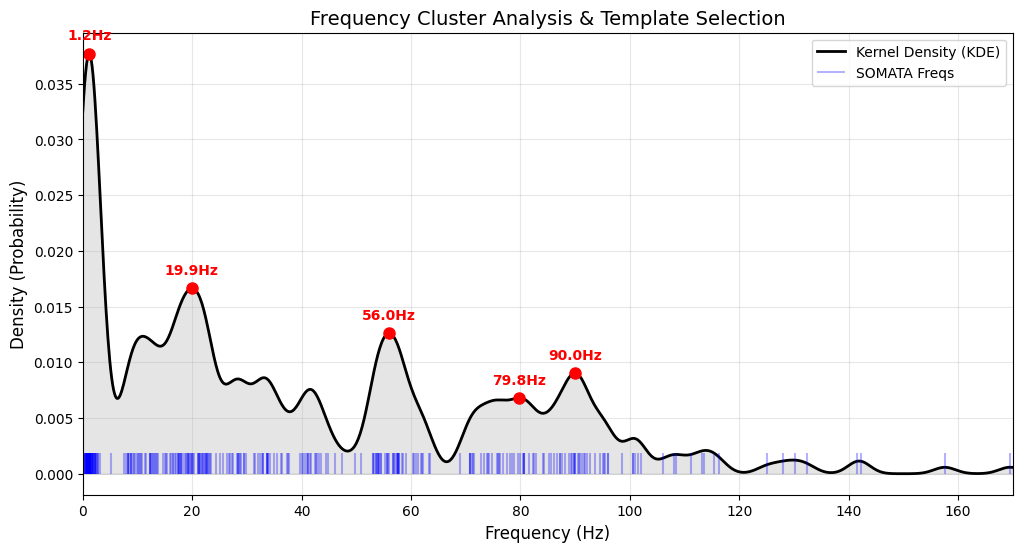

Starting parallel SSPE extraction for 122 channels...
extracted features
running decoder for rule 1.2
sub-10 has mean correlation of 0.591217
nr of frequencies in somata results in total: 346
peak_freqs: [  1.19119119  11.06106106  19.90990991  28.41841842  33.18318318
  41.52152152  55.98598599  75.8958959   79.80980981  90.02002002
 100.57057057 108.3983984  113.84384384 129.83983984 141.92192192
 157.57757758 169.48948949]


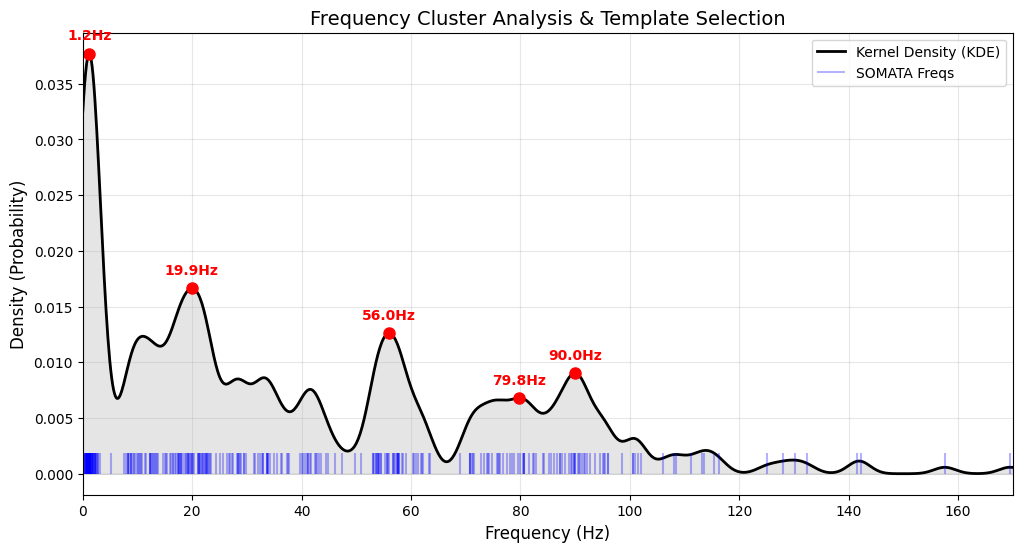

Starting parallel SSPE extraction for 122 channels...
extracted features
running decoder for rule 2
sub-10 has mean correlation of 0.514975


In [20]:
# Build initParams list for all channels according to rule 1.2
eeg_sr = 1024
for participant in ["sub-10"]:
    somata_results = np.load(os.path.join(path_somata,f'{participant}_somata_results.npy'),allow_pickle=True).item()
    
    #gather all channels that have a peak in hg range (that we thus want to use for our base osc template)    
    has_hg_osc = set()
    for idx, data in somata_results.items():
        if any(70 <= f <= 170 for f in data['freqs']):
            #has_hg_osc.add(int(data['channel']))
            has_hg_osc.add(idx)
    hg_subset_results = {idx: somata_results[idx] for idx in has_hg_osc}
    template_freqs = build_density_template(hg_subset_results)
    template_a, template_s = get_template_parameters(hg_subset_results, template_freqs) 
    template_freqs = np.array(template_freqs)
    template_a = np.array(template_a)
    template_s = np.array(template_s)
    
    # Find indices where template frequencies are in the HG range
    hg_mask = (template_freqs >= 70) & (template_freqs <= 170)
    
    hg_only_f = template_freqs[hg_mask]
    hg_only_a = template_a[hg_mask]
    hg_only_s = template_s[hg_mask]
    
    initParams_list = []
    for ch, _ in somata_results.items():
        initParams = {
            "freqs": somata_results[ch]['freqs'],
            "Fs": eeg_sr,
            "ampVec": somata_results[ch]['damping'],
            "sigmaFreqs": somata_results[ch]['sigma2'],
            "sigmaObs": 1,
            "windowSize": 2000,
            "lowFreqBand": None
        }
        if not any(70 <= f <= 170 for f in data['freqs']):
            initParams = {
                "freqs": list(somata_results[ch]['freqs']) + list(hg_only_f),
                "Fs": eeg_sr,
                "ampVec": list(somata_results[ch]['damping']) + list(hg_only_a),
                "sigmaFreqs": list(somata_results[ch]['sigma2']) + list(hg_only_s),
                "sigmaObs": 1,
                "windowSize": 2000,
                "lowFreqBand": None
            }
            #initParams["freqs"].extend(hg_only_f)
            #initParams["ampVec"].extend(hg_only_a)
            #initParams["sigmaFreqs"].extend(hg_only_s)
        
        initParams_list.append(initParams)
    
    run_extract_features(participant, initParams_list, SSPE=True)

from reconstruction_minimal import *
print("running decoder for rule 1.2")
reconstruct(["sub-10"])



# Build initParams list for all channels according to rule 2
for participant in ["sub-10"]:
    somata_results = np.load(os.path.join(path_somata,f'{participant}_somata_results.npy'),allow_pickle=True).item()
      
    has_hg_osc = set()
    for idx, data in somata_results.items():
        if any(70 <= f <= 170 for f in data['freqs']):
            #has_hg_osc.add(int(data['channel']))
            has_hg_osc.add(idx)

    hg_subset_results = {idx: somata_results[idx] for idx in has_hg_osc}
    template_freqs = build_density_template(hg_subset_results)
    template_a, template_s = get_template_parameters(hg_subset_results, template_freqs) 
    
    initParams = {
        "freqs": template_freqs,
        "Fs": eeg_sr,
        "ampVec": template_a,
        "sigmaFreqs": template_s,
        "sigmaObs": 1,
        "windowSize": 2000,
        "lowFreqBand": None
    }
    initParams_list = [initParams]*len(somata_results.items())
    
    run_extract_features(participant, initParams_list, SSPE=True)


print("running decoder for rule 2")
reconstruct(["sub-10"])

In [ ]:
# Build initParams list for all channels according to rule 2

for participant in ["sub-06", "sub-07", "sub-08", "sub-09"]:
    somata_results = np.load(os.path.join(path_somata,f'{participant}_somata_results.npy'),allow_pickle=True).item()
      
    has_hg_osc = set()
    for idx, data in somata_results.items():
        if any(70 <= f <= 170 for f in data['freqs']):
            #has_hg_osc.add(int(data['channel']))
            has_hg_osc.add(idx)

    hg_subset_results = {idx: somata_results[idx] for idx in has_hg_osc}
    template_freqs = build_density_template(hg_subset_results)
    template_a, template_s = get_template_parameters(hg_subset_results, template_freqs) 
    
    initParams = {
        "freqs": template_freqs,
        "Fs": eeg_sr,
        "ampVec": template_a,
        "sigmaFreqs": template_s,
        "sigmaObs": 1,
        "windowSize": 2000,
        "lowFreqBand": None
    }
    initParams_list = [initParams]*len(somata_results.items())
    
    run_extract_features(participant, initParams_list, SSPE=True)
run_decoder(["sub-06", "sub-07", "sub-08", "sub-09"])

In [31]:
participant = "sub-06"
somata_results = np.load(os.path.join(path_somata,f'{participant}_somata_results.npy'),allow_pickle=True).item()

#gather all channels that have a peak in hg range (that we thus want to use for our base osc template)    
has_hg_osc = set()
no_hg_osc = set()
c=0
for idx, data in somata_results.items():
    if any(70 <= f <= 170 for f in data['freqs']):
        #has_hg_osc.add(int(data['channel']))
        has_hg_osc.add(idx)
    else: 
        #if idx<20:
        print(data['freqs'])
        if somata_results[idx]['knee_n_osc'] == 2:
            c = c+1
        no_hg_osc.add(idx)
print(len(no_hg_osc))
print(c)

[  6.05569063   1.07297349 259.76402956]
[  5.71390085   1.03515057 385.02822983]
[  5.50428383   1.01928056 386.40091007]
[  5.606803     1.01036924 385.88904623]
[ 6.14857097  1.06443926 40.85681161]
[ 6.05779988  0.98573173 47.75488648]
[ 1.15316184  6.64647179 25.47958246 55.42961797 58.86195636]
[ 1.08962523  6.58128737 25.05445302 52.71172166]
[ 0.99835505  6.5052817  25.33587759 55.63828571]
[  1.45311366   4.19311031 199.81658792]
[ 6.1977753   1.01396198 44.3030784 ]
[  1.97956698   0.99614672 374.79176343]
[ 6.1453655  1.0958076 40.0271847]
[ 5.82562706  1.04127308 56.69465406]
[ 6.21202771  1.05308394 57.58677686]
[ 5.97539553  0.98014441 25.10372906]
[ 5.96777339  1.03751233 23.42710535]
[ 5.93827259  1.07963364 50.95135811]
[5.83925974 1.58924328 0.26520594]
[  5.12201983   0.83487897 386.86237134]
[ 1.26398343  7.32134887 42.31940163]
[ 7.36755224  1.10745576 42.46474385]
[ 7.51856123  1.14721773 46.49935309]
[ 6.53088783  1.04527765 51.53038878]
[ 1.10966876  6.97813571 

rule 1.1
sub-06 has mean correlation of 0.794323
sub-07 has mean correlation of 0.703751
sub-08 has mean correlation of 0.556479
sub-09 has mean correlation of 0.484244
Mean = 0.6348

Rule 1.2
sub-06 has mean correlation of 0.809089
sub-07 has mean correlation of 0.703751
sub-08 has mean correlation of 0.582714
sub-09 has mean correlation of 0.522065
sub-10 has mean correlation of 0.591217
Mean = 0.6543

Rule 2
sub-06 has mean correlation of 0.794323
sub-07 has mean correlation of 0.677045
sub-08 has mean correlation of 0.523885
sub-09 has mean correlation of 0.533890
Mean = 0.6323

only for sub-09 rule 2 is clearly best. For the rest sub 1.2 is best

/Users/lisa/Library/Python/3.9/lib/python/site-packages/specparam/data/data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)
/Users/lisa/Library/Python/3.9/lib/python/site-packages/specparam/data/data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)


                                                                                                  
                                       POWER SPECTRUM MODEL                                       
                                                                                                  
                       The model was fit with the 'spectral_fit' algorithm                        
              Model was fit to the 0-250 Hz frequency range with 0.50 Hz resolution               
                                                                                                  
                                Aperiodic Parameters ('knee' mode)                                
                                     (offset, knee, exponent)                                     
                                     4.8897, 25.7055, 2.8889                                      
                                                                                                  
          

/Users/lisa/Library/Python/3.9/lib/python/site-packages/specparam/data/data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)
/Users/lisa/Library/Python/3.9/lib/python/site-packages/specparam/data/data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)
/Users/lisa/Library/Python/3.9/lib/python/site-packages/specparam/data/data.py:292: RuntimeWarning: specparam fit warning - skipping frequency == 0, as this causes a problem with fitting.
  warn(msg, category=RuntimeWarning)


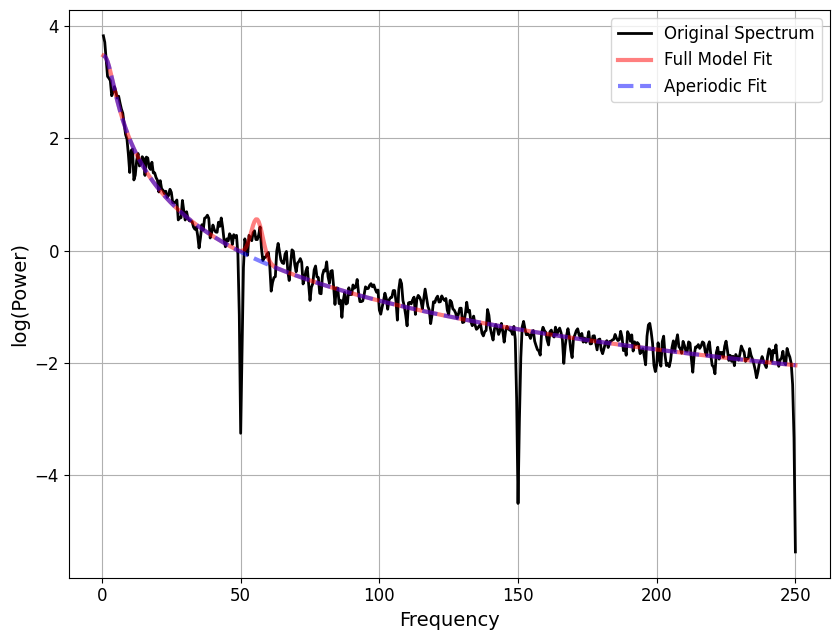

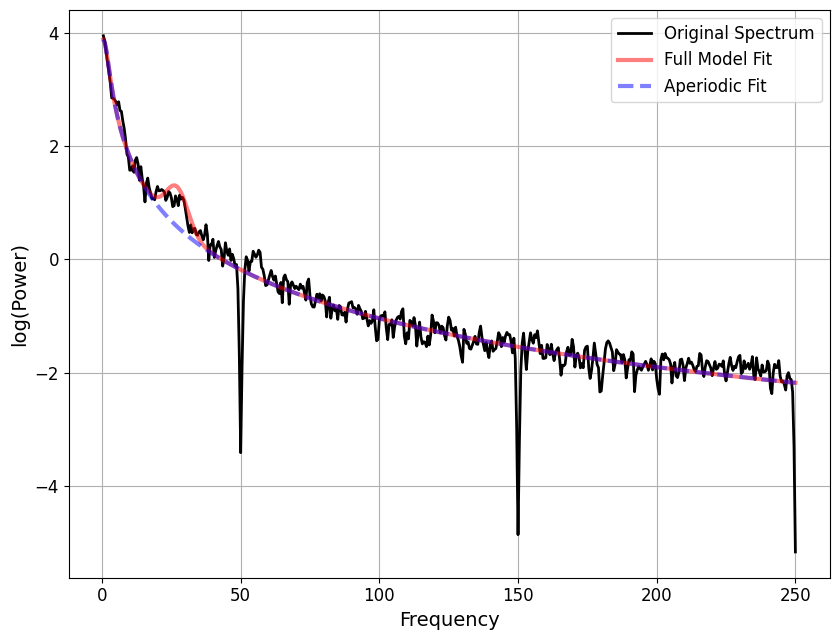

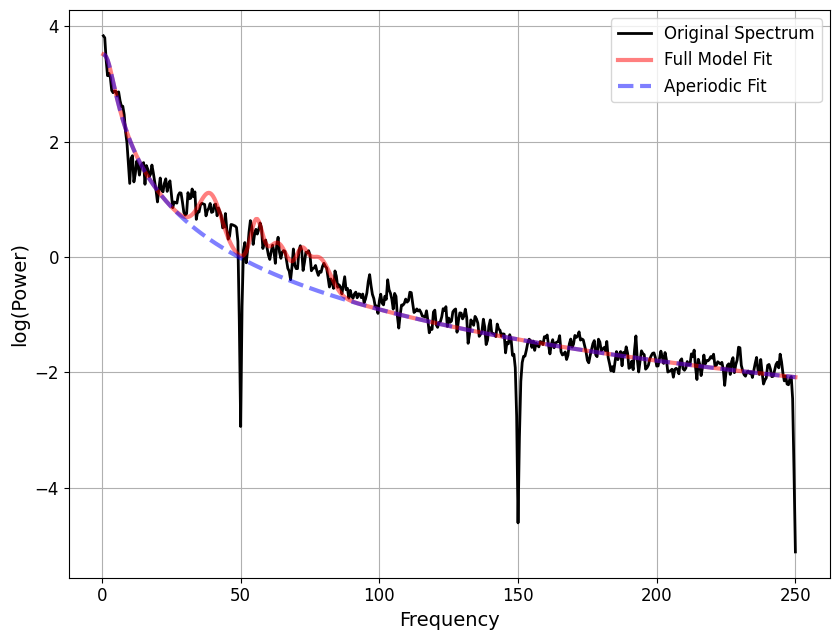

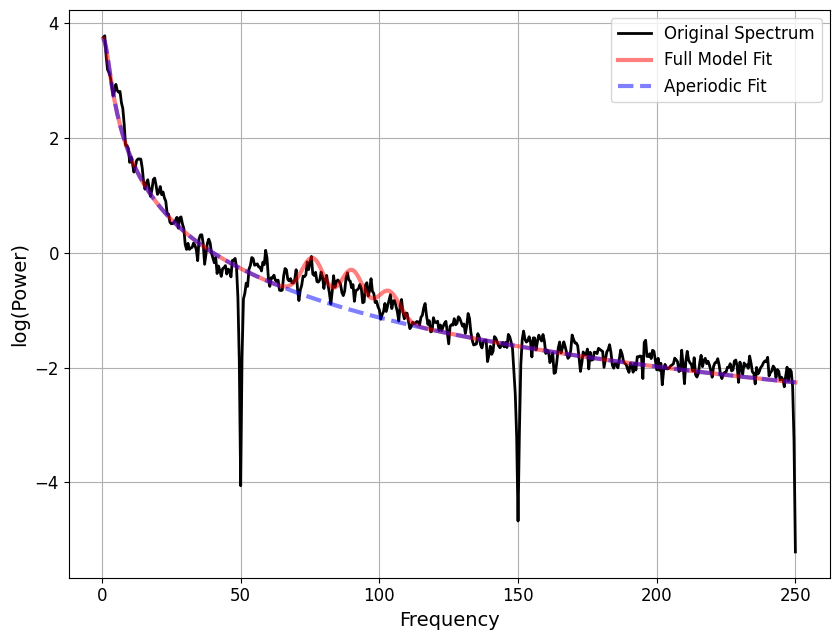

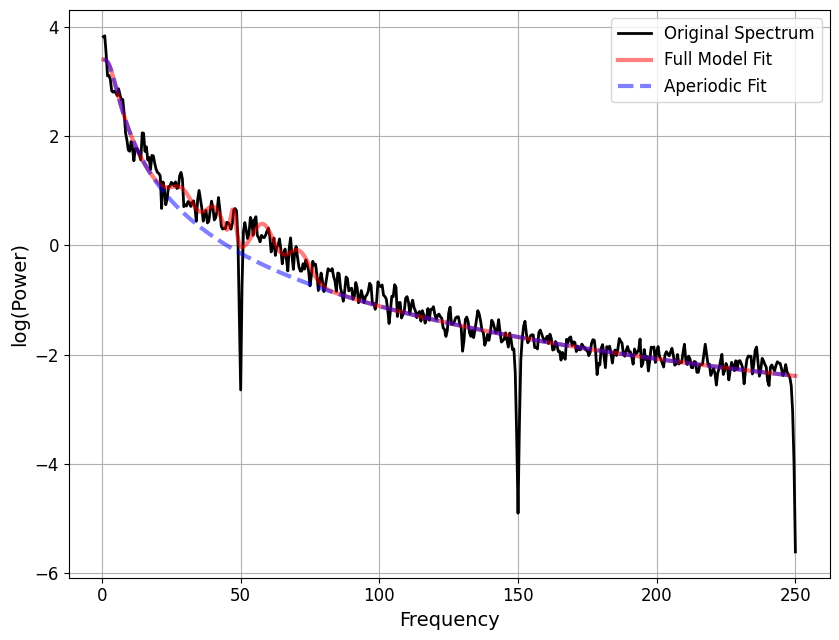

In [11]:
#specparam peak detection

for ch in top_channels:
    # take psd
    freqs, psd = welch(eeg[:, ch], fs=eeg_sr, nperseg=eeg_sr*2)
    
    # initialize and fit SpecParam model
    fm = SpectralModel(peak_width_limits=[2, 8], aperiodic_mode='knee')
    fm.report(freqs, psd, [0, 250], plt_log=False)
    result = fm.results

    print("channel: ", ch)
    print(result.get_results().peak_fit) #first column are the peak frequencies
    print(result.get_results().metrics)

In [12]:
#print specparam results

result = fm.results
print(result.n_peaks)
print(result.get_results().peak_fit) #first column are the peak frequencies
print(result.get_results().metrics)

5
[[29.17882574  0.42945151  3.9999999 ]
 [40.72824455  0.54994271  3.31758065]
 [47.34530282  0.64712287  1.        ]
 [58.22883795  0.74557532  3.99999693]
 [70.96050836  0.53815195  4.        ]]
{'error_mae': np.float64(0.17945995468051434), 'gof_rsquared': np.float64(0.942703355178105)}


In [ ]:
Best channel correlation and the channels peak frequencies
Sub-01
6              Unknown
56    ctx_lh_S_central
5              Unknown
47             Unknown
35             Unknown

Specparam:
6: 8.22
56:  78.18, 180
5:  6.98, 184           
47: 19.69 and 5 freqs > 200           
35: 63.5  

Somata:
6: [4.51] (99, 60, 41, 143), -31703
56:  [ 4.8  23.44](63, 30),  -32211
5: [6.31 1.38](60), -30140            
47: [ 4.03 19.16](65), -19989           
35: [ 6.76  1.9  30.35 63.16], (75, 106) -31151

Decision: 63, 78, 106         

Sub-02
channel: [101  57 108 106 105] ,
 region:  101    Right-Cerebral-White-Matter
57                         Unknown
108          ctx_rh_S_temporal_sup
106    Right-Cerebral-White-Matter
105    Right-Cerebral-White-Matter

Specparam:
channel 101: 83.03578904, 203.50002168
channel 57: 7.16, 13.50, 23.14, 203.33, 218.05
Channel 108: 217
Channel 106: 15.00, 202.74, 236.90
Channel 105: 243.68

Somata:
101: [14.89  0.98  7.42 31.38 72.03], -24231
57: [  7.98   0.63 182.72], -27324
108: [ 7.02 14.33  1.26 27.81] (61/ 56&103), -23208
106: [ 1.07  9.4  22.74] (61), -22234
105: [ 8.56  0.84 21.09] (64), -22057

Decision: 61, 72, 83, 103


Sub-03
Top 5 HG–speech correlated channels: [ 49  48  47  46 101]
with correlations:  [ 0.59024707  0.55861946  0.4307882   0.27109708 -0.24473377]
channel: 49 , region:  Unknown
channel: 48 , region:  ctx_rh_S_circular_insula_inf
channel: 47 , region:  Unknown
channel: 46 , region:  ctx_rh_S_circular_insula_inf
channel: 101 , region:  ctx_lh_G_temp_sup-Lateral

Specparam:
49: 69.3, 104.5, 127.1
48: 232.3
101: 161.5, 168.2, 174

Somata:
49: [ 0.96 13.09 77.05 31.04], -23832
48: [ 1.1  14.91 73.39 32.76], -24799
47: [ 1.35 22.69 67.21] (100), -24629
46: [0.01 67.56 22.68 11.22] (105), -23435
101: [ 0.27 60.76] (85,93) -31203

Decision: 68, 77, 105, 127

Sub-04
Top 5 HG–speech correlated channels: [ 30 108  31  32  36]
with correlations:  [0.52072519 0.39362911 0.38413352 0.34447387 0.31686988]
channel: 30 , region:  Unknown
channel: 108 , region:  ctx_rh_S_central
channel: 31 , region:  ctx_rh_G_pariet_inf-Supramar
channel: 32 , region:  ctx_rh_G_pariet_inf-Supramar
channel: 36 , region:  ctx_rh_Lat_Fis-post

Specparam:
channel 36: [66.79270399  0.54388763  4.]
No peaks found at the other channels

Somata:
30: [ 1.18 13.23 62.74 30.18], -24740
108: [ 2.04 17.31 59.96 37.36], -25215
31: [ 1.76 15.33 62.36 34.46], -25328
32:  [ 1.54  8.96 62.54 33.51 17.86], -23201
36: [ 1.83 14.7  54.2  84.35 34.44], -25446

Decision: 63, 84

Sub-05
Top 5 HG–speech correlated channels: [47 45 44 46 35]
with correlations:  [0.35066116 0.30894677 0.3043469  0.30161759 0.2710452 ]
channel: 47 , region:  ctx_rh_G_temporal_middle
channel: 45 , region:  ctx_rh_G_temporal_middle
channel: 44 , region:  ctx_rh_S_temporal_sup
channel: 46 , region:  ctx_rh_G_temporal_middle
channel: 35 , region:  Right-Cerebral-White-Matter

Specparam:
channel 45: 13.13, 20.11, 24.82, 100.21
channel 46: 12.84, 20.06, 24.50

Somata:
47: [0.18 193 115], -28650
45: [ 0.18 13.38] (22, 100, 180), -27187 
44: [ 0.18 12.71 25.95] (96, 169), -26791 
46: [0.19] (172, 13), -28011
35: [0.17], --29811

Decision: 25(?),100, 170


sub-06:
specparam
channel: 101 , region: ctx_rh_S_circular_insula_inf 
peaks: 76.08932091, 90.1872264, 103.36989196 Hz
{'error_mae': np.float64(0.18756588075857086), 'gof_rsquared': np.float64(0.9184947050427934)}

channel: 26 , region: ctx_lh_G_temp_sup-G_T_transv 
34.90829998, 224.96144074 Hz
{'error_mae': np.float64(0.18699603313551444), 'gof_rsquared': np.float64(0.9382922883142746)}

channel: 8 , region: Left-Cerebral-White-Matter
27.11779933
{'error_mae': np.float64(0.18128730950146338), 'gof_rsquared': np.float64(0.9273456657263243)}

channel:  100 , region: ctx_rh_S_circular_insula_inf,
64.90356669, 94.50000047
{'error_mae': np.float64(0.1802419288513362), 'gof_rsquared': np.float64(0.928559491874099)}

channel:  98 , region: ctx_rh_S_circular_insula_inf
54.27216366, 59.62707486, 64.20271514, 66.75155186, 71.83471434, 81.23954138, 85.2493639, 88.87505882, 97.29788934
{'error_mae': np.float64(0.17750625561836164), 'gof_rsquared': np.float64(0.9335202524220202)}

somata:
101: [1.95] (78, 61 In later iterations)
26: [ 1.09  6.82 18.85 41.21]
8: [ 1.    6.51 25.34 55.64]
100: [1.95] (1, 64, 41, 51 in later iterations)
98: [1.69] (6, 61, 50 in later iterations)

For channels 101, 100 and 98 model chose iteration 0 as best, because Log-likelihood briefly decreases at iteration 1 before improving. so those latter freqs I put  in the brackets

[64, 76, 90, 103] seem most informative frequencies (note, they all come from channels in ctx_rh_S_circular_insula_inf)



Sub-07:
specparam
channel: 96 , region:  ctx_lh_S_temporal_transverse
No peaks
{'error_mae': np.float64(0.1771620753451968), 'gof_rsquared': np.float64(0.8765308196252938)}
channel: 95 , region:  Left-Cerebral-White-Matter
No peaks
{'error_mae': np.float64(0.1677550224145677), 'gof_rsquared': np.float64(0.8815019679305702)}
channel: 94 , region:  Left-Cerebral-White-Matter
No peaks
{'error_mae': np.float64(0.17463185712443077), 'gof_rsquared': np.float64(0.8721652763231073)}
channel: 97 , region:  ctx_lh_S_temporal_transverse
160.77252024 Hz
{'error_mae': np.float64(0.1789235662843417), 'gof_rsquared': np.float64(0.8776777660670632)}
channel: 98 , region:  ctx_lh_G_temp_sup-Plan_tempo
140.00001662 Hz
{'error_mae': np.float64(0.17396662648965322), 'gof_rsquared': np.float64(0.8735891888809086)}

Somata model: 
Channel 96:  [ 2.19 18.62 77.71 36.81]
Channel 95: [ 2.08 19.62 74.86 38.41]
Channel 94: [  1.54  11.57  71.41  38.59  23.86 122.98 190.8 ]
Channel 97: [3.]
Channel 98: [2.82]

decision: use 77 (is in ch 95 and 96 of somata model) and 140 (ch 98 from spacparam). both informative for speech.
can experiment with adding 2 and 19 


Sub-08: 
specparam:
All top 5 channels in Left-Cerebral-White-Matter
And all peak frequencies >200 or <20 Hz

somata:
Channel 22    Left-Cerebral-White-Matter
logL: -21864, freqs: [ 1.57 13.44 28.69] (75)

Channel 31    Left-Cerebral-White-Matter
logL: -23011, freqs: [9.91 0.76] (65)

Channel 24    Left-Cerebral-White-Matter
logL: -21800, freqs: [ 1.02 12.01 66.04 29.79]

Channel 5     Left-Cerebral-White-Matter
logL: -22658, freqs: [ 5.42 17.62] (71)

Channel 7     Left-Cerebral-White-Matter
logL: -22456, freqs: [ 7.6  18.39  0.94] (82)

decision: 66, 75


Sub-09:
specparam:
all peak frequencies >170 or <15 Hz

Somata:
channel: 90 , region:  Left-Cerebral-White-Matter
[1.67] (63, 55, 125)

channel: 89 , region:  Left-Cerebral-White-Matter
[0.98] - no HGA peaks, and logL only decreased

channel: 91 , region:  ctx_lh_S_central
[1.75] (60)

channel: 6 , region:  Left-Cerebral-White-Matter
[  2.09 281.18 140.4  207.91]

channel: 7 , region:  ctx_lh_G_orbital
[ -1.36 208.62 129.45]

Decision: [60, 125] Hz


Sub-10
Top 5 HG–speech correlated channels: [33 32 34 35 36]
with correlations:  [0.55811939 0.54847478 0.48608983 0.40804694 0.37206639]
channel: 33 , region:  Right-Cerebral-White-Matter
channel: 32 , region:  ctx_rh_Lat_Fis-post
channel: 34 , region:  ctx_rh_G_temp_sup-G_T_transv
channel: 35 , region:  ctx_rh_G_temp_sup-Plan_tempo
channel: 36 , region:  ctx_rh_G_temp_sup-Plan_tempo

In the raw multitaper spectogram I could visually see multiple burst of a few seconds at ~110 Hz

Specparam:
channel 33: 93.26300761, 110.18012996 
channel 32: 92.67805208, 103.95464473, 111.84238554 
channel 34: 110.23393933

Somata:
33: [  2.3   20.74 106.06  59.62], logL -22946
32:  [  2.24  22.17 100.58  57.4 ], logL  -24265
34: [  0.93  25.72  10.37 104.05  61.64], logL -20715
35: [  0.85  10.99  57.69 101.72  30.69], logL -19502
36: [ 0.84 10.45 73.95 29.42], logL -19905

Decision: 60, 92, 105